# <center> Matrix factorization</center>

План:
- SVD разложение и специфика для рекомендательной системы
- Разновидности SVD: Compact SVD, Truncated SVD, Funk SVD, SVD++, Time SVD++. 
- t-SNE визуализация

In [25]:
import warnings
warnings.filterwarnings("ignore")

from math import sqrt
import numpy as np
import pandas as pd
import pickle
import seaborn as sns
import scipy as sp
import scipy.sparse as scs
import matplotlib
import matplotlib.pyplot as plt
from numpy.linalg import svd
from sklearn.manifold import TSNE
from sklearn.metrics import r2_score
from sklearn.preprocessing import LabelEncoder
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm.notebook import tqdm
from PIL import Image
from IPython.display import display
from ipywidgets import interact, widgets

%matplotlib inline

matplotlib.rcParams['figure.figsize'] = (12, 10)
np.set_printoptions(2, suppress=True)
plt.rcParams.update({'font.size': 14})

Для сравнения, вспомним, что из себя представляли User-based & Item-based smilarity подходы.

<img src='../week3/images/Similarity.png' width=700>

### Что такое MF

**Матричная факторизация** (Matrix Factorization, MF) - это матричное разложение, которое является простой моделью латентных эмбеддингов. 

Будем раскладывать исходную матрицу интеракций $A$ на несколько матриц (обычно 2 или 3), которые будут ее аппроксимировать при перемножении $PQ^T$.

Таким образом:

* Матрица интеракций $A \in R^{m \times n} $ <br> (далее в обозначениях также будет фигурировать как R - матрица рейтингов)
* Матрица эмбеддингов пользователей $P \in R^{m \times dim}$, где ряд $i$ - это эмбеддинг пользователя $i$. <br>
* Матрица эмбеддингов айтемов $Q \in R^{n \times dim}$, где ряд $j$ - это эмбеддинг айтема $j$.

Пара $(i, j)$ в $PQ^T$ - это скалярное произведение $<P_i, Q_j>$ эмбеддингов пользователя i и айтема j, которое должно быть близко к $A_{ij}$

<img src='../week3/images/MF.png' width=700>

$$ A ≈ (\tilde U \tilde \Sigma)^T \cdot \tilde V^T = P^T \cdot Q.$$

**Определение целевой функции для MF**

Одной из интуитивно понятных целевых функций для MF является квадрат расстояния. Для этого минимизируйте сумму квадратов ошибок по всем парам наблюдаемых записей: 

$$min_{P \in R^{m\times d}, Q \in R^{n\times d}} \sum_{(i,j) \in obs} (A_{ij} - <P_i, Q_j>)^2$$

Вы можете решать эту квадратичную задачу с помощью сингулярного разложения матрицы (SVD). 

## SVD 

<img src='https://www.dataminingapps.com/wp-content/uploads/2020/02/svd2.png'>

$$ R = U \Sigma V^T$$



Сингулярные значения диагональной матрицы содержательно представляют собой меру важности каждого из скрытых факторов, которые используются для приближения исходной матрицы $A$. Чем больше сингулярное значение, тем больше вклад этого скрытого фактора в исходные данные. Сингулярные значения считаются как квадратные корни из собственных значений. В контексте рекомендательных систем, они позволяют определить, какие скрытые факторы (например, какие -то определяющие паттерны в данных по пользователям и айтемам) играют более важную роль при создании рекомендаций.

Когда мы собираем матрицу интеракций только по положительным парам, появляется проблема для SVD - сингулярное разложение не определено для неполнных матриц, а у нас матрица неполная. 
Что делать? 


Cделаем матрицу разрежененной (разреженная от неполной отличается тем, что неизвестные значения доопределены нулями), но при этом хранить и делать вычислительные операции мы все равно можем в sparse формате.

Сделаем сначала симуляцию такой матрицы:

In [27]:
A = np.zeros((20, 5))
non_zero_count = int(A.size * 0.2)
non_zero_indices = np.random.choice(A.size, non_zero_count, replace=False)
A.ravel()[non_zero_indices] = np.random.randint(0, 6, non_zero_count)
A

array([[0., 0., 3., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 2., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 4.],
       [0., 0., 0., 0., 0.],
       [0., 0., 5., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 3.],
       [0., 2., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 2., 0., 0., 1.],
       [4., 0., 0., 0., 0.],
       [0., 0., 0., 0., 3.],
       [0., 0., 0., 0., 4.],
       [0., 0., 0., 0., 0.],
       [2., 1., 0., 0., 0.],
       [0., 0., 0., 0., 2.],
       [1., 0., 0., 2., 0.]])

In [29]:
U, s, V = svd(A)
U.shape, s.shape, V.shape

((20, 20), (5,), (5, 5))

s - одномерный массив с сингулярными значениями. Сингулярные значения в этом массиве упорядочены в порядке убывания.

In [31]:
S = np.zeros(A.shape)
S[:len(s), :len(s)] = np.diag(s)
S

array([[7.46, 0.  , 0.  , 0.  , 0.  ],
       [0.  , 5.83, 0.  , 0.  , 0.  ],
       [0.  , 0.  , 4.66, 0.  , 0.  ],
       [0.  , 0.  , 0.  , 3.6 , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 1.94],
       [0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  ]])

Обратите внимание, что нижние нулевые строки нужны, чтобы составить ортонормированный базис (боковые матрицы  U и V образуют базис векторов в пространствах пользователей и айтемов соответственно. Базис - это набор векторов, который может быть использован для представления любого вектора в данном пространстве.) 

In [33]:
U @ S @ V

array([[-0.,  0.,  3.,  0.,  0.],
       [-0., -0., -0., -0., -0.],
       [ 0.,  2., -0., -0.,  0.],
       [ 0.,  0., -0.,  0.,  0.],
       [ 0.,  0., -0.,  0.,  4.],
       [ 0.,  0.,  0.,  0.,  0.],
       [-0.,  0.,  5., -0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.],
       [ 0.,  1., -0.,  0.,  3.],
       [ 0.,  2., -0., -0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.],
       [ 0.,  2., -0., -0.,  1.],
       [ 4.,  0.,  0., -0., -0.],
       [ 0.,  0., -0.,  0.,  3.],
       [ 0.,  0., -0.,  0.,  4.],
       [ 0.,  0.,  0.,  0.,  0.],
       [ 2.,  1., -0., -0.,  0.],
       [ 0.,  0., -0.,  0.,  2.],
       [ 1., -0.,  0.,  2.,  0.]])

In [35]:
np.allclose(A, U @ S @ V)

True

Давайте сначала повизуализируем, что значит выбор компонент из SVD на примере картинок и как это влияет на качество восстановления на практике:

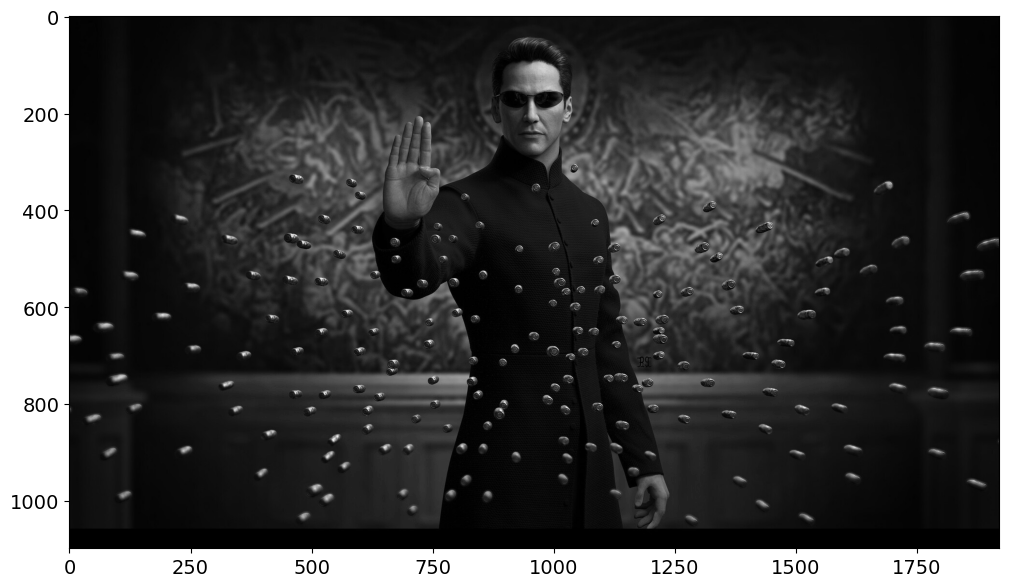

In [37]:
nice_pic = np.array(Image.open('../week3/images/neo.png').convert('L'))
plt.imshow(nice_pic, cmap='gray');

In [39]:
U, s, V = svd(nice_pic)
print((U.shape, s.shape, V.shape))

((1098, 1098), (1098,), (1920, 1920))


In [41]:
S = np.zeros(nice_pic.shape)
S[:len(s), :len(s)] = np.diag(s)
print(S.shape)
S

(1098, 1920)


array([[55357.44,     0.  ,     0.  , ...,     0.  ,     0.  ,     0.  ],
       [    0.  , 12610.05,     0.  , ...,     0.  ,     0.  ,     0.  ],
       [    0.  ,     0.  , 10234.32, ...,     0.  ,     0.  ,     0.  ],
       ...,
       [    0.  ,     0.  ,     0.  , ...,     0.  ,     0.  ,     0.  ],
       [    0.  ,     0.  ,     0.  , ...,     0.  ,     0.  ,     0.  ],
       [    0.  ,     0.  ,     0.  , ...,     0.  ,     0.  ,     0.  ]])

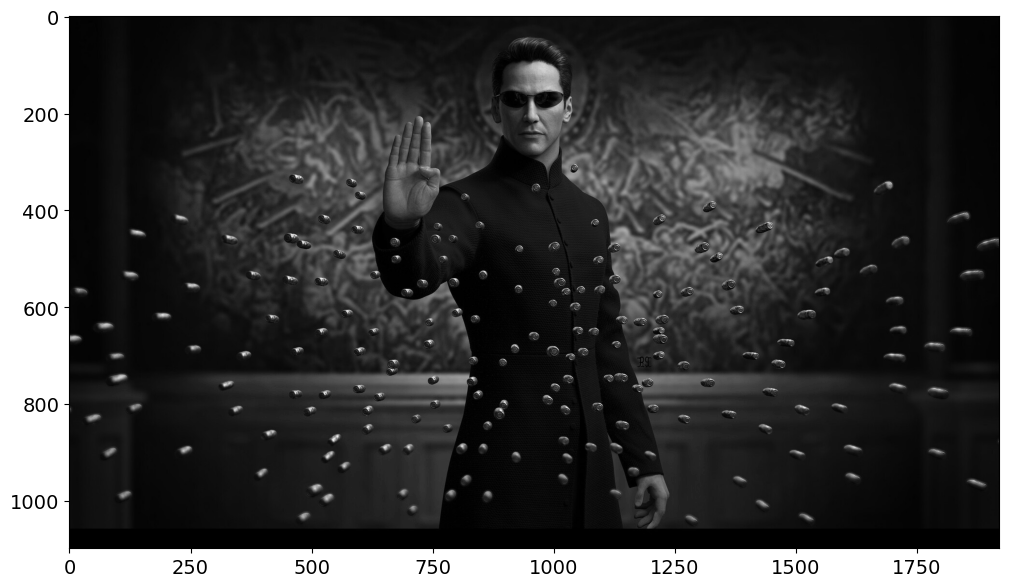

In [43]:
plt.imshow(U @ S @ V, cmap='gray');

In [45]:
def reshape_for_k(k: int, U, s, V):
    U_new = U[: , :k]
    S = np.zeros((U.shape[0], V.shape[1]))
    S[:len(s), :len(s)] = np.diag(s)
    S_new = S[: k, : k]
    V_new = V[: k, :]
    return U_new @ S_new @ V_new

reshape_for_k(1, U, s, V)

array([[2.  , 2.  , 2.04, ..., 2.29, 2.23, 2.11],
       [2.  , 2.01, 2.04, ..., 2.29, 2.23, 2.12],
       [2.01, 2.01, 2.05, ..., 2.29, 2.24, 2.12],
       ...,
       [0.  , 0.  , 0.  , ..., 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , ..., 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , ..., 0.  , 0.  , 0.  ]])

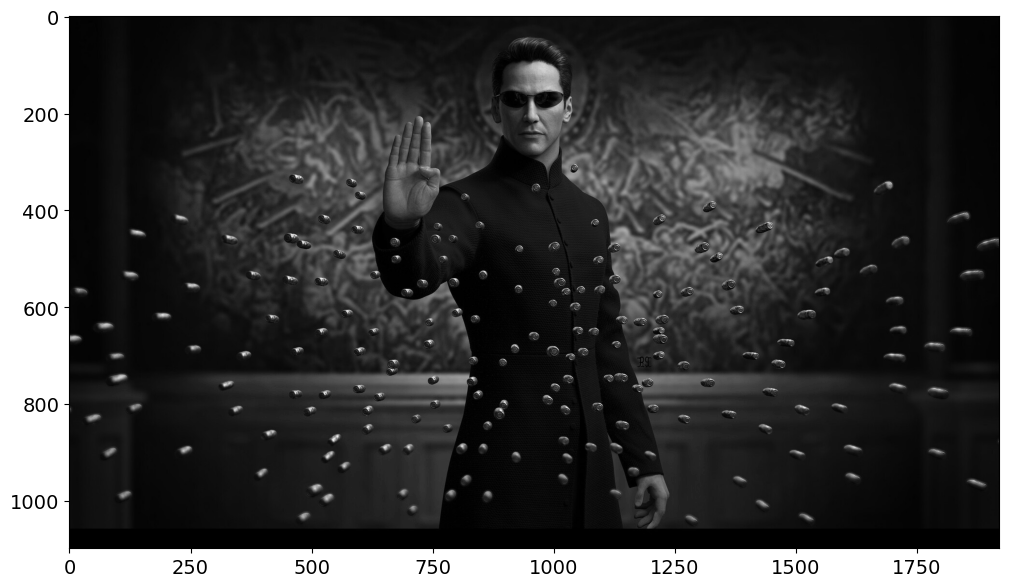

In [57]:
plt.imshow(reshape_for_k(1098, U, s, V), cmap='gray');

## Hands-on рекомендательной системы на MF

Попробуем применить SVD на табличных данных для задачи рекомендации. Возьмем датасет из пользователей и фильмов.

In [59]:
ratings = pd.read_csv('../week3/data/movies_ratings.csv')
ratings

,userId,movieId,rating,timestamp,title
0,1,31,2.5,1260759144,Dangerous Minds
1,7,31,3.0,851868750,Dangerous Minds
2,31,31,4.0,1273541953,Dangerous Minds
3,32,31,4.0,834828440,Dangerous Minds
4,36,31,3.0,847057202,Dangerous Minds
...,...,...,...,...,...
99845,664,64997,2.5,1343761859,H.G. Wells' War of the Worlds
99846,664,72380,3.5,1344435977,The Box
99847,665,129,3.0,995232528,Pie in the Sky
99848,665,4736,1.0,1010197684,Summer Catch


In [61]:
num_users, num_movies = ratings.userId.nunique(), ratings.movieId.nunique()
num_users, num_movies

(671, 9025)

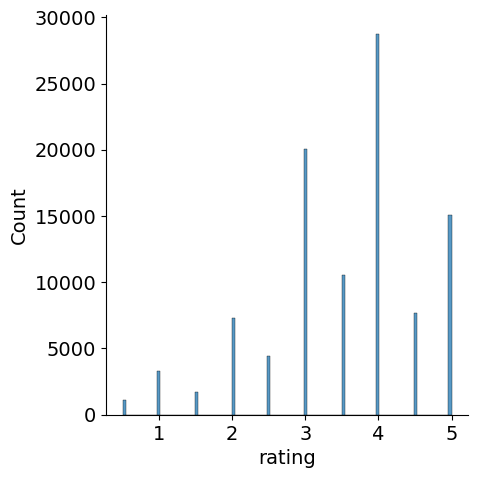

In [63]:
sns.displot(ratings.rating);

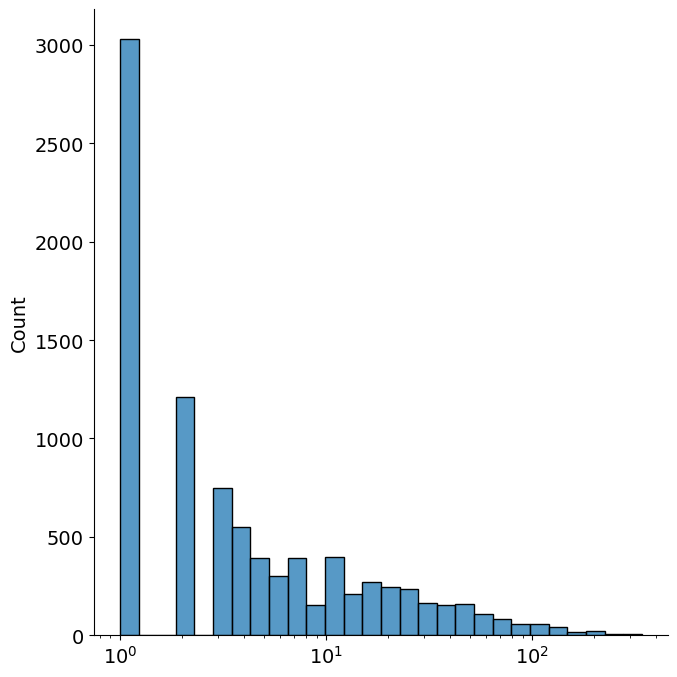

In [65]:
sns.displot(ratings.groupby('movieId').size(), log_scale=True, height=7);

Разделим выборку на обучение и тест следующим образом: для каждого пользователя в тестовую выборку попадут 10 его последних оценок.

In [67]:
train_ratings, test_ratings = [], []
num_test_samples = 10

for userId, user_data in ratings.groupby('userId'):
    train_ratings += [user_data[:-num_test_samples]]
    test_ratings += [user_data[-num_test_samples:]]

train_ratings = pd.concat(train_ratings)
test_ratings = pd.concat(test_ratings)
train_ratings.shape, test_ratings.shape

((93140, 5), (6710, 5))

In [69]:
user_encoder, item_encoder = LabelEncoder(), LabelEncoder()
train_ratings['userId'] = user_encoder.fit_transform(train_ratings['userId'])
train_ratings['movieId'] = item_encoder.fit_transform(train_ratings['movieId'])


user_ids = np.array(train_ratings['userId'].tolist())
movie_ids = np.array(train_ratings['movieId'].tolist())
user_ratings = np.array(train_ratings["rating"].tolist())
print ('num of users:',train_ratings['userId'].nunique())
print ('num of movies:',train_ratings['movieId'].nunique())

num of users: 671
num of movies: 8044


In [71]:
R = scs.coo_array((train_ratings.rating, (train_ratings.userId, train_ratings.movieId)), 
                       shape=(num_users, num_movies)).tocsr()
matrix = R.toarray()

In [73]:
U, s, V = svd(matrix)
U.shape, s.shape, V.shape

((671, 671), (671,), (9025, 9025))

In [75]:
S = np.zeros(matrix.shape)
S[:len(s), :len(s)] = np.diag(s)
print(S.shape)
S

(671, 9025)


array([[514.18,   0.  ,   0.  , ...,   0.  ,   0.  ,   0.  ],
       [  0.  , 241.23,   0.  , ...,   0.  ,   0.  ,   0.  ],
       [  0.  ,   0.  , 198.9 , ...,   0.  ,   0.  ,   0.  ],
       ...,
       [  0.  ,   0.  ,   0.  , ...,   0.  ,   0.  ,   0.  ],
       [  0.  ,   0.  ,   0.  , ...,   0.  ,   0.  ,   0.  ],
       [  0.  ,   0.  ,   0.  , ...,   0.  ,   0.  ,   0.  ]])

In [77]:
preds_matrix = U @ S @ V

In [79]:
preds_matrix

array([[ 0.,  0., -0., ...,  0.,  0.,  0.],
       [-0.,  0.,  0., ...,  0.,  0.,  0.],
       [-0., -0.,  0., ...,  0.,  0.,  0.],
       ...,
       [ 0., -0.,  0., ...,  0.,  0.,  0.],
       [ 4.,  0., -0., ...,  0.,  0.,  0.],
       [ 5.,  0.,  0., ...,  0.,  0.,  0.]])

In [81]:
np.allclose(matrix, preds_matrix)

True

In [87]:
k = 20
df = pd.DataFrame(data=(zip(matrix[0, :], preds_matrix[0, :])), 
                  columns=['init', 'preds']).sort_values(by='init', ascending=False)
df['preds'] = df['preds'].astype('float32')
df.sort_values(by='preds', ascending=False).head(k)

,init,preds
875,4.0,4.000000e+00
1024,3.5,3.500000e+00
781,3.0,3.000000e+00
805,3.0,3.000000e+00
30,2.5,2.500000e+00
1028,2.0,2.000000e+00
984,2.0,2.000000e+00
960,2.0,2.000000e+00
851,2.0,2.000000e+00
990,2.0,2.000000e+00


Обратите внимание, что список рекомендаций выше - смешанный, у него в топе те айтемы, которые уже были в матрице интеракций пользователя. Когда нам нужно сделать только новые рекомендации - можем профильтровать. 

In [89]:
df.sort_values(by='preds', ascending=False).head(k)[df.init == 0]

,init,preds
268,0.0,5.175027e-14
2262,0.0,4.118234e-14
500,0.0,3.387568e-14
1516,0.0,3.211320e-14
1972,0.0,3.204555e-14
31,0.0,2.997602e-14
2990,0.0,2.996214e-14
96,0.0,2.846161e-14
2169,0.0,2.828987e-14
2181,0.0,2.665923e-14


### Другие типы SVD

$$ R = U \Sigma V^T$$

- **Full SVD**
$$ UU^T = U^TU = I_M$$
$$ VV^T = V^TV = I_N,$$

где $M$ x $M$ - размер матрицы $U$, $M$ x $N$ - размер матрицы $\Sigma$, $N$ x $N$ - размер матрицы $V$. 

- **Compact SVD**

Берем матрицу $\Sigma$ по размеру ранга. Compact SVD не усекает данные и предоставляет точное разложение исходной матрицы.

$$ l = rank\{R\}$$
$$ U^TU = V^TV = I_l,$$

где $M$ x $l$ - размер матрицы $U$, $l$ x $l$ - размер матрицы $\Sigma$, $l$ x $N$ - размер матрицы $V$.

- **Truncated SVD**
 
Берем первые k компонент диагональной матрицы $\Sigma$.

$$ k << l = rank{R}$$
$$ U^TU = V^TV = I_k,$$

где $M$ x $k$ - размер матрицы $U$,  $k$ x $k$ - размер матрицы $\Sigma$, $k$ x $N$ - размер матрицы $V$.

**Важно** - обратите внимание, что матрица R теперь не равна разложению, она становится приближенной.

При формализации задачи разложения нужно соблюсти много условий. Например, что матрицы $U$ и $V$ должны быть ортогональны друг другу. На практике, пренебрегаем выполянется ли условие ортогональности, и просто решаем задачу приближения исходной матрицу перемножением двух новых, $U$ и $V$, и тогда нет единственности решения. 
Обучение новых матриц чаще всего реализуется через SGD. Не без вытекающих проблем - накопление численных ошибок, дисбаланса матриц (одна растет, другая падает), но что можно нивелировать, например, через регуляризацию и кастомизацию штрафов. Например,если не хотим все айтемы штрафовать одинаково, т.к. есть item popularity bias, можно добавлять нормирование каждого айтема и домножить на свой собственный коэффициент. 

In [91]:
def reshape_for_k(k: int, U, s, V):
    U_new = U[: , :k]
    S = np.zeros((U.shape[0], V.shape[1]))
    S[:len(s), :len(s)] = np.diag(s)
    S_new = S[: k, : k]
    V_new = V[: k, :]
    return U_new @ S_new @ V_new

reshape_for_k(2, U, s, V)

array([[0.02, 0.01, 0.01, ..., 0.  , 0.  , 0.  ],
       [0.54, 0.21, 0.1 , ..., 0.  , 0.  , 0.  ],
       [0.63, 0.25, 0.08, ..., 0.  , 0.  , 0.  ],
       ...,
       [0.26, 0.1 , 0.04, ..., 0.  , 0.  , 0.  ],
       [0.46, 0.18, 0.06, ..., 0.  , 0.  , 0.  ],
       [1.8 , 0.72, 0.24, ..., 0.  , 0.  , 0.  ]])

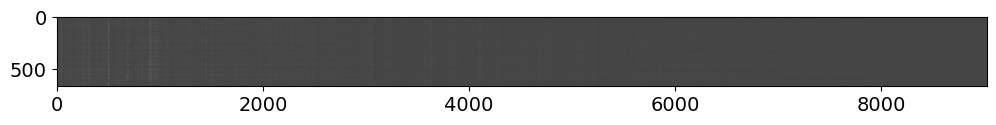

In [93]:
plt.imshow(reshape_for_k(50, U, s, V), cmap='gray');

In [ ]:
@interactive(k=widgets.IntSlider(min=1, max=1098))

def plot_figure(k):
    plt.title(f'k = {k}')
    new_img = reshape_for_k(k, U, s, V)
    plt.imshow(new_img, cmap='gray');

**Сколько компонент брать?**

Мы не хотим получить точно такую же матрицу, как была у нас в самом начале (overfit), но нам и не подойдет вариант с новой матрицей, где значения сильно разнятся с исходными (underfit).

Какие есть способы сравнить два набора данных? Можно построить простые графики метрики качества задачи восстановления исходных данных.

<img src='https://raw.githubusercontent.com/anamarina/RecSys_course/2021/week2/images/svd3.png' width=500>

В качестве метрики можем добавить коэффициент объясненной дисперсии и разреженность. Например, **Explained variance ratio (EVR)** и **Sparsity** — разреженность данных.
Как бы вы проинтерпретировали этот график?

<img src='https://raw.githubusercontent.com/anamarina/RecSys_course/main/week2/images/svd2.png' height=700 width=500>

Какие еще факторы важны при отборе количества главных компонент?

1. Качество самих рекомендаций (метрики ранжирования на оффлайн и онлайн) данных
2. Вычислительные ресурсы (RAM, жетский диск, требования к скорости расчетов и т.д.)

**t-SNE визуализация с Truncated SVD**

Иногда, когда делают честное SVD и ортогонализацию, компонентны можно распознать (популярность, жанр или что-то еще). На практике получить валидную интерпретацию тяжело, потому что это линейные комбинации разных характеристик и MF плохо интерпретируемы. Но можно пробовать отрисовывать главные компоненты (например, берем две компоненты и строим график с векторами айтемов на них) и делать визуальный анализ по кластерами примеров.  

Можно взять только часть компонент, например, первые 10 компонент. 

In [143]:
R = pd.pivot_table(ratings, values='rating', index=['userId'],columns=['movieId'], fill_value=0).to_numpy()
print ('{0}x{1} user by user matrix'.format(*R.shape))

671x9025 user by user matrix


In [145]:
train_user = R[:500, :1200]
test_user = R[500:, 1200:]

In [147]:
from sklearn.decomposition import TruncatedSVD

user_svd = TruncatedSVD(n_components=10)
user_features = user_svd.fit_transform(train_user)

print ("user_features.shape = {0}".format(user_features.shape))

user_features.shape = (500, 10)


In [149]:
tsne = TSNE(perplexity=5, n_components=3, init="pca", n_iter=1000)
plot_only = 15
coords_3d = tsne.fit_transform(user_features[:plot_only, :])

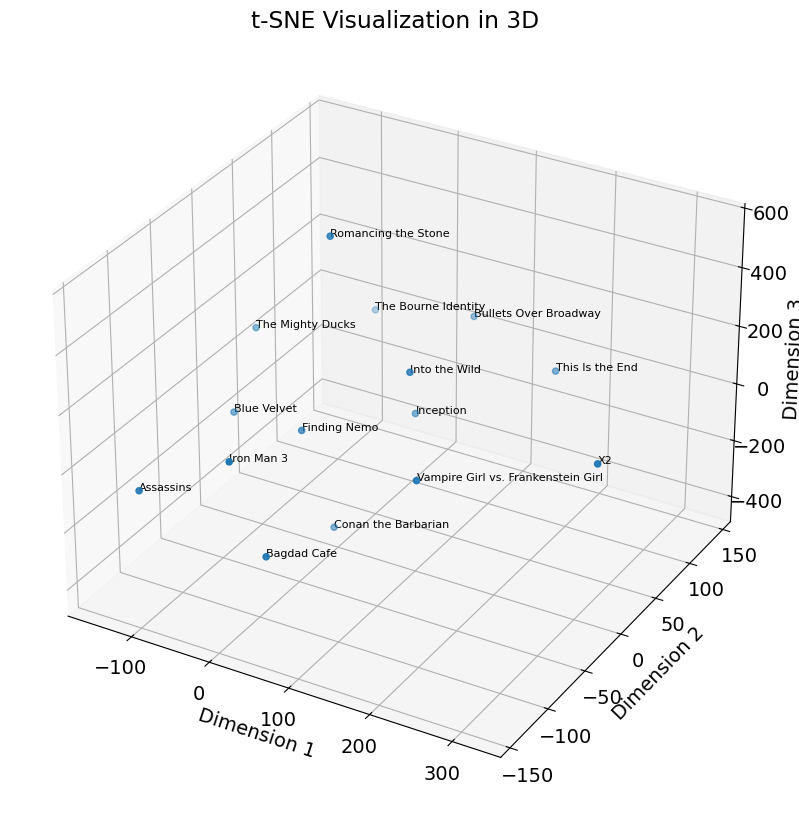

In [151]:
df_tsne_3d = pd.DataFrame(coords_3d, columns=['tsne_1', 'tsne_2', 'tsne_3'])

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

df = ratings.sample(frac=1).reset_index(drop=True)
ax.scatter(df_tsne_3d['tsne_1'], df_tsne_3d['tsne_2'], df_tsne_3d['tsne_3'])

for i, txt in enumerate(df['title'].iloc[:plot_only]):
    ax.text(df_tsne_3d['tsne_1'][i], df_tsne_3d['tsne_2'][i], df_tsne_3d['tsne_3'][i], '%s' % (txt), size=8, zorder=1)

ax.set_title('t-SNE Visualization in 3D')
ax.set_xlabel('Dimension 1')
ax.set_ylabel('Dimension 2')
ax.set_zlabel('Dimension 3')

plt.show();

- Правда ли, что у похожих айтемов будут похожие эмбеддинги?


Да, но смотря что вкладывать в похожесть.
Близость эмбеддингов по метрике расстояния (например, cosine similarity) интрепретируется не как похожие друг на друга фильмы по характеристикам (описание, жанр, режиссер и др.), а как часто совстречаемые фильмы у похожей по истории просмотров группы пользователей (которые им релевантны в порядке сортировки убывающей нормы векторов). Если угол между айтемами будет мал, то и предсказания у пользователей будут похожими за счет высокой частоты появления близкого фильма в их рекомендациях. 

### Обучение матриц вместо разложения

$$r_{ui} = \hat r_{ui} = p^T_{u} q_i$$

$$ \Theta = \{p_u, q_i| u \in U, i \in I\}$$

$$\sum_{(u,i) \in D}(r_{ui} - \hat r_{ui})^2 + \lambda \sum_{\theta in \Theta}) ||\theta||^2 = \sum_{(u,i) \in D}(r_{ui} - p_u^T q_i)^2 + \lambda \sum_{u \in U} ||p_u||^2 + \lambda \sum_{i \in I} ||q_i||^2 $$

### Funk SVD

Funk SVD подход получил широкую [известность](https://sifter.org/simon/journal/20061211.html) после конкурса Netflix Prize в 2006 году, , хотя в индустрии подход не получил большой популярности, так как градиентный спуск сильно сложнее распараллелить, чем, например, ALS при не менее лучшем качестве.

<img src='../week3/images/FunkSVD.png' width=700>

Помимо скалярного произведения, включает еще смещения по пользователю $b_u$ и айтему $b_i$. Тогда:

$$\hat r_{u,i} = \mu + b_u + b_i + q_{i}^{T}p_{u},$$

где $\mu$ - глобальное среднее по всем оценкам в данных. Тогда задача оптимизации сводится к:

$$ \sum(r_{u,i} - \hat r_{u,i}) ^ 2 +     \lambda(b_i^2 + b_u^2 + ||q_i||^2 + ||p_u||^2),$$

где $\lambda$ - параметр регуляризации.

Оптимизация через стохастический градиентный спуск:

$$b_u \leftarrow b_u + \gamma (e_{ui} - \lambda b_u)$$
$$b_i \leftarrow b_i + \gamma (e_{ui} - \lambda b_i)$$  
$$p_u \leftarrow p_u + \gamma (e_{ui} \cdot q_i - \lambda p_u)$$
$$q_i \leftarrow q_i + \gamma (e_{ui} \cdot p_u - \lambda q_i),$$

где $\gamma$ - это learning rate, <br>
$e_{ui} =  r_{ui} - \hat r_{u,i} = r_{u,i} - (\mu + b_u + b_i + q_{i}^{T}p_{u})$ ошибка алгоритма на паре $(u, i)$.

In [ ]:
n_movie = train_ratings.movieId.nunique() # 8044
n_user = train_ratings.userId.nunique() # 671

embedding_size = 10
lr = 0.001
reg = 0.01

In [159]:
n_movie, n_user 

(8044, 671)

In [69]:
user_ids = torch.LongTensor(train_ratings['userId'].values)
movie_ids = torch.LongTensor(train_ratings['movieId'].values)
user_ratings = torch.FloatTensor(train_ratings['rating'].values) # kernel

На пальцах:

$prediction = user\_embedding[userId] \cdot movie\_embedding[movieId] + user\_bias[userId] + movie\_bias[movieId] + global\_bias$


Функция потерь (L):

$||prediction - rating||^2 + \lambda (||user\_embedding||^2 + ||movie\_embedding||^2 + ||user\_bias||^2 + ||movie\_bias||^2)$

$\lambda$ - регуляризация с L2 loss. 

In [39]:
class MatrixFactorization(nn.Module):
    
    def __init__(self, n_user, n_movie, embedding_size):
        super(MatrixFactorization, self).__init__()
        self.user_embedding = nn.Embedding(n_user, embedding_size)
        self.movie_embedding = nn.Embedding(n_movie, embedding_size)
        self.user_bias_embedding = nn.Embedding(n_user, 1)
        self.movie_bias_embedding = nn.Embedding(n_movie, 1)
        self.global_bias = nn.Parameter(torch.zeros(1))

    def forward(self, user, movie):
        u = self.user_embedding(user)
        m = self.movie_embedding(movie)
        u_bias = self.user_bias_embedding(user).squeeze()
        m_bias = self.movie_bias_embedding(movie).squeeze()
        predicted_rating = torch.sum(u * m, dim=1) + u_bias + m_bias + self.global_bias
        return predicted_rating

In [40]:
model = MatrixFactorization(n_user, n_movie, embedding_size)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=reg)

In [41]:
batch_size = 16
n_epoch = 3

for epoch in range(n_epoch):
    for start in range(0, len(user_ratings) - batch_size, batch_size):
        end = start + batch_size
        user_batch = user_ids[start:end]
        movie_batch = movie_ids[start:end]
        rating_batch = user_ratings[start:end]

        optimizer.zero_grad()
        outputs = model(user_batch, movie_batch)
        loss = criterion(outputs, rating_batch)
        loss.backward()
        optimizer.step()

    print("RMSE", torch.sqrt(loss).item())

movie_embeddings = model.movie_embedding.weight.detach().numpy()

RMSE 0.6754335761070251
RMSE 0.6437369585037231
RMSE 0.6400254964828491


### SVD++

[Factorization Meets the Neighborhood](https://www.cs.rochester.edu/twiki/pub/Main/HarpSeminar/Factorization_Meets_the_Neighborhood-_a_Multifaceted_Collaborative_Filtering_Model.pdf) - оригинальная статья предложенного алгоритма, где предлагается использовать хронологический порядок истории взаимодействий.

Обычно рассматривается только множество айтемов с явным отликом, $R(u)$, но чаще всего у нас имеются неявные данные. 
Метод SVD++ можем учитывать множество айтемов с неявным откликом, $N(u)$:


$\hat{r}_{ui} =\mu + b_u + b_i + q^T_i \left( p_u + |N(u)|^{-1/2} \sum_{j \in N(u)} y_j \right) ,$



$\Theta = \{ \mu, b_u, b_i, p_u, q_i, y_i| u \in U, i \in I\} .$


Множество $N(u)$ можно заменить на $R(u)$, т.к. всегда выполняется $R(u) \subset N(u)$, и считать как item-item рекомендации.

### Time SVD++

Часто в истории взаимодействий пользователей существует информация о времени (например, в формате timestamp или какой-то даты, когда взаимодействие произошло). Как это использовать?

Автор статьи [Collaborative Filtering with Temporal Dynamics](http://citeseerx.ist.psu.edu/viewdoc/download?doi=10.1.1.379.1951&rep=rep1&type=pdf) из Yahoo предложил добавить зависимость от времени в модель SVD++, поскольку предпочтения пользователей динамично меняются, также как и смещения по юзерам и айтемам:


$\hat{r}_{ui}(t) =\mu + b_u(t) + b_i(t) + q^T_i \left( p_u(t) + |R(u)|^{-1/2} \sum_{j \in R(u)} y_j \right) .$


Для item bias:

$b_i(t) = b_i + b_{i, \text{Bin}(t)}$


Для user bias:

$b_i(t) = b_i + \alpha_u \cdot \text{dev}_u(t) + b_{u, t} \quad\quad\quad\quad \text{dev}_u(t) = \text{sign}(t - t_u) \cdot |t - t_u|^{\beta}$

Для эмбеддингов пользователей похожий трюк:

$p_u(t) = (p_{u1}(t), \dots, p_{uf}(t))^T$:
$p_{uk}(t) = p_{uk} + \alpha_{uk} \cdot \text{dev}_u(t) + p_{uk, t}. $



### Еще из лайфхаков про матричное разложение просто на примере приближенного подсчета SVD

Есть интересное свойство с использованием ортогональности. 

$$ R = U\Sigma V^T $$

Если хотим рассмотреть только одну из ортогональных матриц, например, U, можем сделать следующее:

$$ R = U(\Sigma V^T) = U \tilde V ^T ,$$

где $\Sigma V^T$ дает нам новую матрицу, которая является проекцией матрицы R в пространство, описываемое матрицей U. 
Таком образом, рассматриваем $\tilde V ^T$ как проекцию R в новое пространство, которое состоит только из левых сингулярных векторов U.

Матрицу V можно рассматреть по аналогии:

$$ R = (U\Sigma) V^T = \tilde U  V ^T.$$

На практике, когда это полезно - допустим, у нас непропорционально много пользователей или продуктов, можно хранить только матрицу по меньшей размерности.

<ins>Проверочные вопросы на понимание:</ins> 

*  1. В чем может быть практическая польза хранить не исходную матрицу, а две/три новые матрицы? 

*Помним, что обычно dim << n и dim << m, таким образом, на практике нам дешевле хранить в памяти две более компактные матрицы, чем исходную*

*  2. Что важнее для MF - абсолютное значение оценки или порядок между оценками айтемов?

* 3. В чем будут недостатки максимально точной аппроксимации исходной матрицы для рекомендательных систем (т.е. один к одному воспроизвести значения исходной материцы интеракций)?
     
* 4. Как проинтерпретировать матрицы U, S, V с точки зрения юзеров и айтемов?

* 5. Как получить рекомендации для i-го пользователя после разложения матрицы интеракций?
 
*  6. Считают ли матричные фаткоризации похожесть пользователей или айтемов напрямую? 

* 7.  Можно ли проинтпретировать выученные характеристики и латентные векторы?
 
* 8. Правда ли, что из-за большого количества пропусков в матрице полученное SVD решение будет слишком шумным, и его придется каждый раз рассчитывать заново при добавлении новых пользователей или айтемов?
 